In [1]:
import cv2
from ultralytics import YOLO
import matplotlib.pyplot as plt

import os
import sys

parent = os.path.abspath("..")
if parent not in sys.path:
    sys.path.append(parent)

from src.config import settings

In [5]:
best_model: YOLO = YOLO(
    model="../models/runs/translation/train5-yolo/weights/best.pt",
    task="classify",
)

best_model.info()

YOLO11n-cls summary: 86 layers, 1,564,410 parameters, 0 gradients, 3.3 GFLOPs


(86, 1564410, 0, 3.2789504)

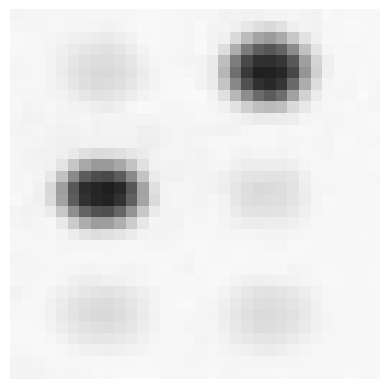

In [6]:
img = cv2.imread("../data/processed/kaggle/yolo/test/i/i1.JPG0dim_aug_0_blur.jpg")
plt.imshow(img)
plt.axis("off")
plt.show()

In [7]:
predictions = best_model.predict(img, conf=0.7)
prediction = predictions[0]
probs = prediction.probs

conf = probs.top1conf
cls = probs.top1
character = settings.CHARACTERS_LOWERCASE[cls]

print(f"Confidence: {conf}")
print(f"Class: {cls} -- {character}")


0: 32x32 i 0.91, e 0.07, f 0.01, h 0.00, j 0.00, 2.7ms
Speed: 2.1ms preprocess, 2.7ms inference, 0.0ms postprocess per image at shape (1, 3, 32, 32)
Confidence: 0.9141288995742798
Class: 8 -- i


In [8]:
# TODO: Find a way to implement exactly the top5 predictions! Awesome

display(probs.top5, probs.top5conf)
sum((i * conf for i, conf in zip(probs.top5, probs.top5conf)))

[8, 4, 5, 7, 9]

tensor([0.9141, 0.0728, 0.0059, 0.0021, 0.0015], device='cuda:0')

tensor(7.6621, device='cuda:0')